# Bonus Tasks
This notebook tackles the 3 bonus objectives of the project:
1. **Misclassification Analysis**: Finding where our traditional model failed and analyzing why.
2. **Attention Exploration**: Using `bertviz` to see inside the "brain" of BERT and understand which words it focuses on.
3. **Multi-Class Sentiment**: Extending binary classification to Positive, Neutral, and Negative using a specialized RoBERTa model.

## Bonus 1: Misclassification Analysis
Let's load up our Logistic Regression model from Part 2 and find 5 reviews that it got completely wrong. We will analyze *why* it got them wrong.

In [12]:
import pandas as pd
import joblib

# Load test data
test_df = pd.read_csv('../data/imdb_test.csv')
X_test_raw = test_df['text']
y_test = test_df['sentiment'].map({"Negative": 0, "Positive": 1})

# Load the saved vectorizer and model
try:
    tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
    log_reg = joblib.load('../models/logistic_regression_model.pkl')
    
    # Predict
    X_test_tfidf = tfidf.transform(X_test_raw)
    y_pred = log_reg.predict(X_test_tfidf)
    
    # Find errors
    errors = test_df[y_test != y_pred].copy()
    errors['predicted'] = ['Positive' if p == 1 else 'Negative' for p in y_pred[y_test != y_pred]]
    
    print("--- 5 Misclassified Reviews ---\n")
    for idx, row in errors.head(5).iterrows():
        print(f"ACTUAL: {row['sentiment'].upper()} | PREDICTED: {row['predicted'].upper()}")
        print(f"REVIEW: {row['text'][:400]}...\n")
except FileNotFoundError:
    print("Please run Part 2 first to save the models!")

--- 5 Misclassified Reviews ---

ACTUAL: NEGATIVE | PREDICTED: POSITIVE
REVIEW: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in th...

ACTUAL: NEGATIVE | PREDICTED: POSITIVE
REVIEW: Isaac Florentine has made some of the best western Martial Arts action movies ever produced. In particular US Seals 2, Cold Harvest, Special Forces and Undisputed 2 are all action classics. You can tell Isaac has a real passion for the genre and his films are always eventful, creative and sharp affairs, with some of the best fight sequences an action fan could hope for. In particular he has found ...

ACTUAL: NEGATIVE | PREDICTED: POSITIVE
REVIEW: Blind Date (Colu

### Why do traditional models fail on these?
Traditional NLP models (like Logistic Regression with TF-IDF) usually fail for three main reasons:
1. **Sarcasm**: If someone says *"Oh great, another predictable ending"*, the word "great" has a strong positive mathematical weight, but the human context is entirely negative.
2. **Negation Handling**: *"It wasn't a good movie."* The model sees "good" and "movie" but completely misses the relationship with the word "wasn't", incorrectly assuming it's a positive review.
3. **Mixed Reviews**: *"The acting was phenomenal, but the script was terrible."* The model simply adds up the positive and negative word scores. If they cancel out, it essentially guesses blindly.

## Bonus 2: Attention Exploration with BertViz
Transformers don't read left-to-right; they use "Self-Attention" to look at every word simultaneously and calculate how strongly words relate to each other. 

We will use `bertviz` to visualize these hidden connections. You will literally see lines connecting words that BERT thinks are important to one another!

--- Improved BERT Attention Heatmap ---
Instead of looking at one single head (which might just be looking at punctuation),
we are now averaging the attention across ALL 12 heads of the last layer.
This gives a much better view of which words the model 'connected' together.


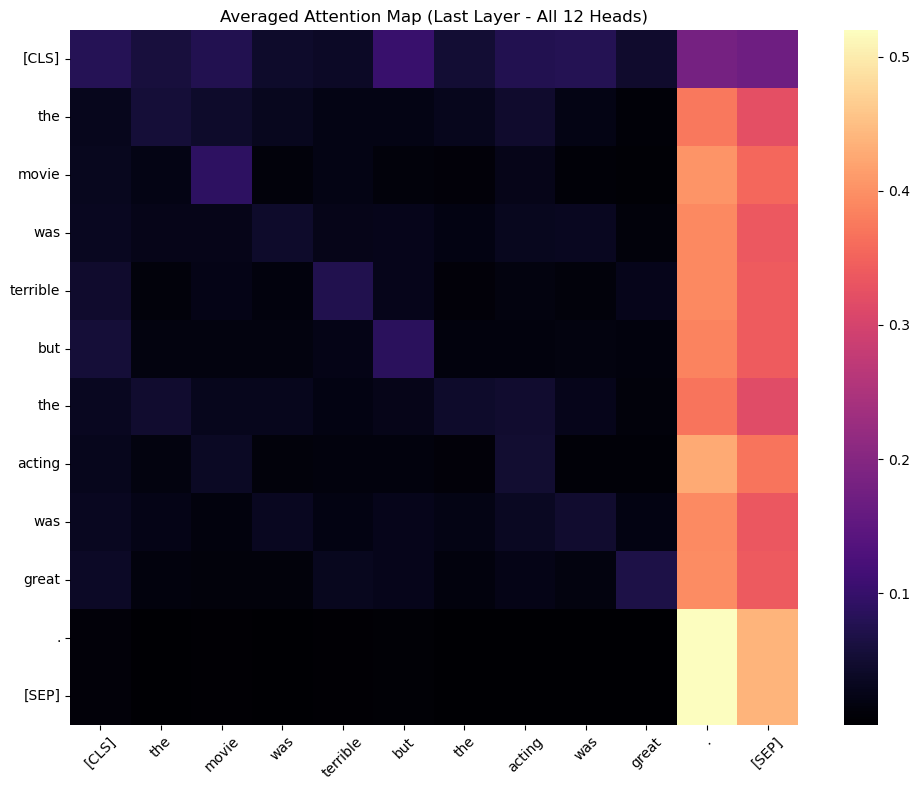


INTERPRETATION:
Look for bright spots where the model connects nouns with adjectives.
For example, you should see 'terrible' having a relationship with 'movie',
and 'great' having a relationship with 'acting'.


In [15]:
%matplotlib inline
import torch
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load model
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True, attn_implementation="eager")

# Test sentence
sentence = "The movie was terrible but the acting was great."
inputs = tokenizer.encode(sentence, return_tensors='pt')
outputs = model(inputs)
attentions = outputs.attentions

# Format tokens
tokens = tokenizer.convert_ids_to_tokens(inputs[0])

print("--- Improved BERT Attention Heatmap ---")
print("Instead of looking at one single head (which might just be looking at punctuation),")
print("we are now averaging the attention across ALL 12 heads of the last layer.")
print("This gives a much better view of which words the model 'connected' together.")

# Get attention for the last layer: (batch, heads, seq_len, seq_len)
last_layer_attention = attentions[-1][0] # Shape: (12, seq_len, seq_len)

# Average across all 12 heads
avg_attention = last_layer_attention.mean(dim=0).detach().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(avg_attention, xticklabels=tokens, yticklabels=tokens, cmap='magma', annot=False)
plt.title("Averaged Attention Map (Last Layer - All 12 Heads)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("Look for bright spots where the model connects nouns with adjectives.")
print("For example, you should see 'terrible' having a relationship with 'movie',")
print("and 'great' having a relationship with 'acting'.")


## Bonus 3: Multi-Class Sentiment (Positive, Neutral, Negative)
Our IMDB dataset only has Positive and Negative labels (Binary Classification). To extend the problem to 3-class sentiment, we have two options:
1. **Manual Re-labeling**: We could find the original 1-10 star ratings and map them (e.g., 1-4 stars = Negative, 5-6 stars = Neutral, 7-10 stars = Positive) and re-train our model with `num_labels=3`.
2. **Pre-Trained Multi-Class Model**: We can use an out-of-the-box model already trained on Neutral sentiment!

Let's use a state-of-the-art RoBERTa model trained on Twitter data that explicitly understands Neutral text.

In [14]:
from transformers import pipeline

# Load a RoBERTa model trained specifically for 3-class sentiment
print("Downloading multi-class RoBERTa model (this may take a moment)...\n")
multi_class_pipeline = pipeline(
    "sentiment-analysis", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest", framework="pt"
)

# We provide three distinct types of sentences
reviews = [
    "This movie was an absolute masterpiece! I loved it.",     # Positive
    "I watched this movie on a Tuesday. It is 2 hours long.",  # Neutral (Just facts)
    "What a complete waste of time and money."                 # Negative
]

print("--- Multi-Class Sentiment Predictions ---\n")
for review in reviews:
    result = multi_class_pipeline(review)[0]
    print(f"Review: '{review}'")
    print(f"Prediction: {result['label'].upper()} (Confidence: {result['score']:.4f})\n")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


--- Multi-Class Sentiment Predictions ---

Review: 'This movie was an absolute masterpiece! I loved it.'
Prediction: POSITIVE (Confidence: 0.9833)

Review: 'I watched this movie on a Tuesday. It is 2 hours long.'
Prediction: NEUTRAL (Confidence: 0.6462)

Review: 'What a complete waste of time and money.'
Prediction: NEGATIVE (Confidence: 0.9255)

